# Failure case visualization -- 100-epoch baseline vs. arunodhayan zero-shot

Visual companion to the numeric failure-case comparison (see `baselinerun/research_log.md`).
Loads the raw CT volume, ground truth, our baseline's prediction, and arunodhayan's zero-shot
lowres prediction for the worst-scoring held-out cases (LOSO, scroll 26010, 129 cases), and
displays orthogonal mid-slices side by side.

Reminder of the numeric finding this exists to make visible: TopoScore collapses much harder
than SurfaceDice on the worst cases for *both* models (topo ~0.01-0.09 while surface_dice
stays 0.6-0.98) -- the goal here is to actually *see* what that looks like, not just the
number.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile

DATASET_ROOT = Path("/mnt/workspace/code/datasets/vesuvius-challenge-surface-detection")
RAW_IMAGES_DIR = DATASET_ROOT / "train_images"
GT_LABELS_DIR = DATASET_ROOT / "train_labels"
BASELINE_PRED_DIR = Path(
    "/mnt/workspace/code/outputs/training_run/nnUNet_results/Dataset100_VesuviusSurface/"
    "nnUNetTrainerSeeded_100epochs__nnUNetResEncUNetMPlans__3d_lowres/fold_0/validation"
)
ARUNO_PRED_DIR = Path("/mnt/workspace/code/finetune/zeroshot_predictions")

BASELINE_SCORE_JSON = Path("/mnt/workspace/code/outputs/training_run/baseline_fold0_official_score.json")
ARUNO_SCORE_JSON = Path("/mnt/workspace/code/finetune/arunodhayan_lowres_zeroshot_official_score.json")

In [2]:
with open(BASELINE_SCORE_JSON) as f:
    baseline_scores = json.load(f)["per_case"]
with open(ARUNO_SCORE_JSON) as f:
    aruno_scores = json.load(f)["per_case"]

df = pd.read_csv(DATASET_ROOT / "train.csv")
df["id"] = df["id"].astype(str)
case_to_scroll = dict(zip(df["id"], df["scroll_id"]))

common_cases = sorted(set(baseline_scores) & set(aruno_scores))
print(f"{len(common_cases)} cases scored by both models (should be all 129 LOSO held-out cases)")

129 cases scored by both models (should be all 129 LOSO held-out cases)


## Worst cases, and where the two models' worst-10 lists overlap

In [3]:
N = 10
worst_baseline = sorted(common_cases, key=lambda c: baseline_scores[c]["score"])[:N]
worst_aruno = sorted(common_cases, key=lambda c: aruno_scores[c]["score"])[:N]
overlap = [c for c in worst_baseline if c in worst_aruno]

print(f"Worst {N} for baseline:", worst_baseline)
print(f"Worst {N} for arunodhayan zero-shot:", worst_aruno)
print(f"\nOverlap ({len(overlap)} cases -- hard for both models, not model-specific):", overlap)

Worst 10 for baseline: ['2147357641', '1679790444', '3788871542', '3064717657', '3878283235', '2881190689', '2142002305', '3513954919', '263322541', '236296322']
Worst 10 for arunodhayan zero-shot: ['1679790444', '3878283235', '2147357641', '263322541', '236296322', '636928528', '3554743381', '719197630', '3321304167', '2473381112']

Overlap (5 cases -- hard for both models, not model-specific): ['2147357641', '1679790444', '3878283235', '263322541', '236296322']


## Volume loading + visualization helpers

Displays 3 orthogonal mid-slices (axial / coronal / sagittal) x 4 volume types
(raw CT, ground truth, baseline prediction, arunodhayan zero-shot prediction) as a 4x3 grid.
Ground truth / predictions use a fixed 3-color map: background=black, surface=white, ignore=red
(so the ignore-label border, if visible in a slice, doesn't get mistaken for a real prediction).

In [4]:
from matplotlib.colors import ListedColormap

LABEL_CMAP = ListedColormap(["black", "white", "red"])  # 0=background, 1=surface, 2=ignore


def load_case_volumes(case_id: str) -> dict[str, np.ndarray]:
    return {
        "raw": tifffile.imread(RAW_IMAGES_DIR / f"{case_id}.tif"),
        "ground truth": tifffile.imread(GT_LABELS_DIR / f"{case_id}.tif"),
        "baseline pred": tifffile.imread(BASELINE_PRED_DIR / f"{case_id}.tif"),
        "arunodhayan zero-shot pred": tifffile.imread(ARUNO_PRED_DIR / f"{case_id}.tif"),
    }


def mid_slices(vol: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    z, y, x = (s // 2 for s in vol.shape)
    return vol[z, :, :], vol[:, y, :], vol[:, :, x]


def plot_case(case_id: str) -> None:
    vols = load_case_volumes(case_id)
    scroll = case_to_scroll.get(case_id, "?")
    bscore = baseline_scores[case_id]
    ascore = aruno_scores[case_id]

    fig, axes = plt.subplots(4, 3, figsize=(10, 13))
    view_names = ["axial", "coronal", "sagittal"]

    for row, (name, vol) in enumerate(vols.items()):
        slices = mid_slices(vol)
        is_label_vol = name != "raw"
        for col, (view_name, sl) in enumerate(zip(view_names, slices)):
            ax = axes[row, col]
            if is_label_vol:
                ax.imshow(sl, cmap=LABEL_CMAP, vmin=0, vmax=2, interpolation="nearest")
            else:
                ax.imshow(sl, cmap="gray", interpolation="nearest")
            if row == 0:
                ax.set_title(view_name)
            if col == 0:
                ax.set_ylabel(name, fontsize=10)
            ax.set_xticks([])
            ax.set_yticks([])

    fig.suptitle(
        f"case {case_id} (scroll {scroll})\n"
        f"baseline: score={bscore['score']:.3f} topo={bscore['topo_score']:.3f} sd={bscore['surface_dice']:.3f}  |  "
        f"arunodhayan: score={ascore['score']:.3f} topo={ascore['topo_score']:.3f} sd={ascore['surface_dice']:.3f}",
        fontsize=10,
    )
    fig.tight_layout()
    plt.show()

## Worst overlapping cases -- hard for both models

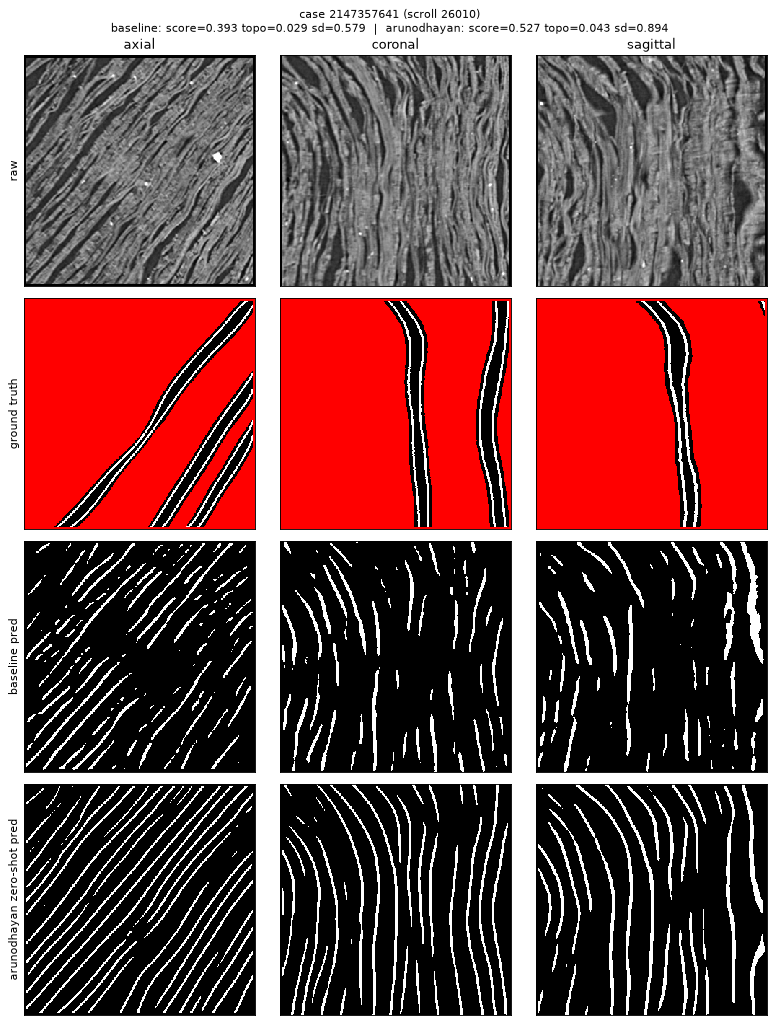

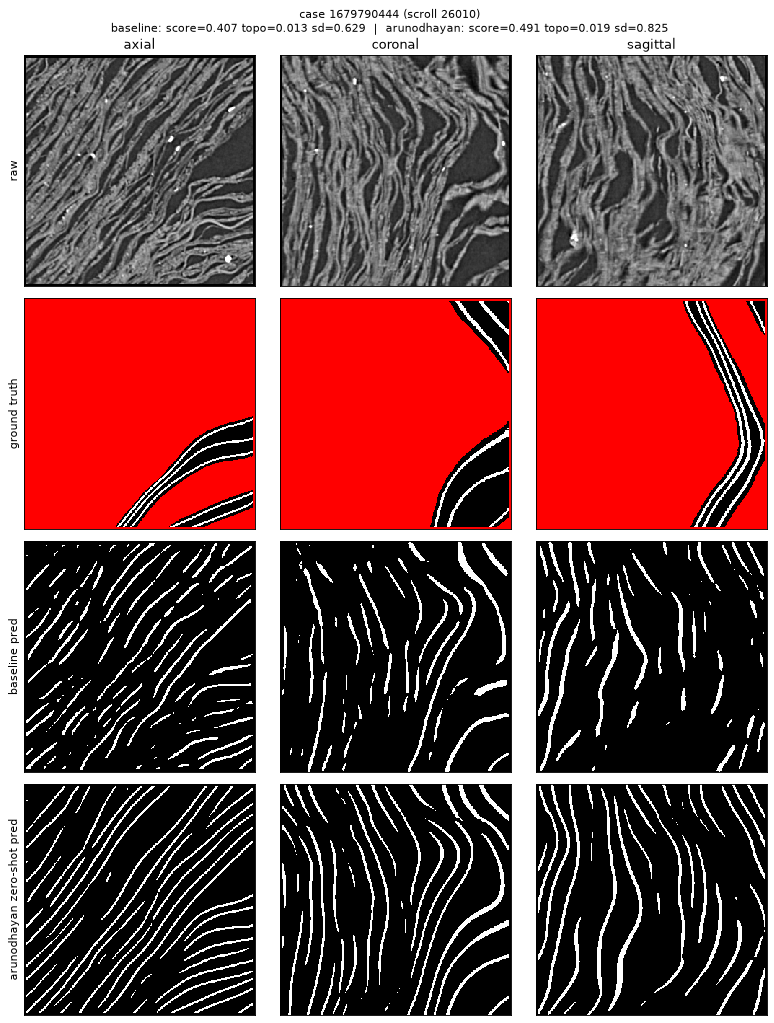

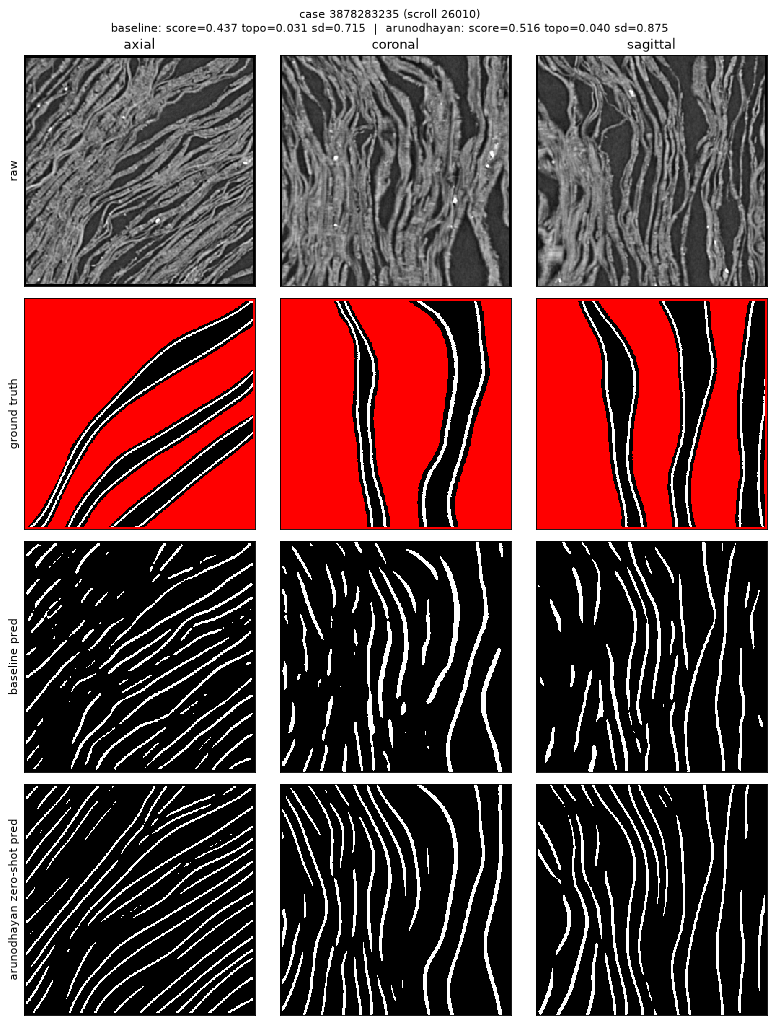

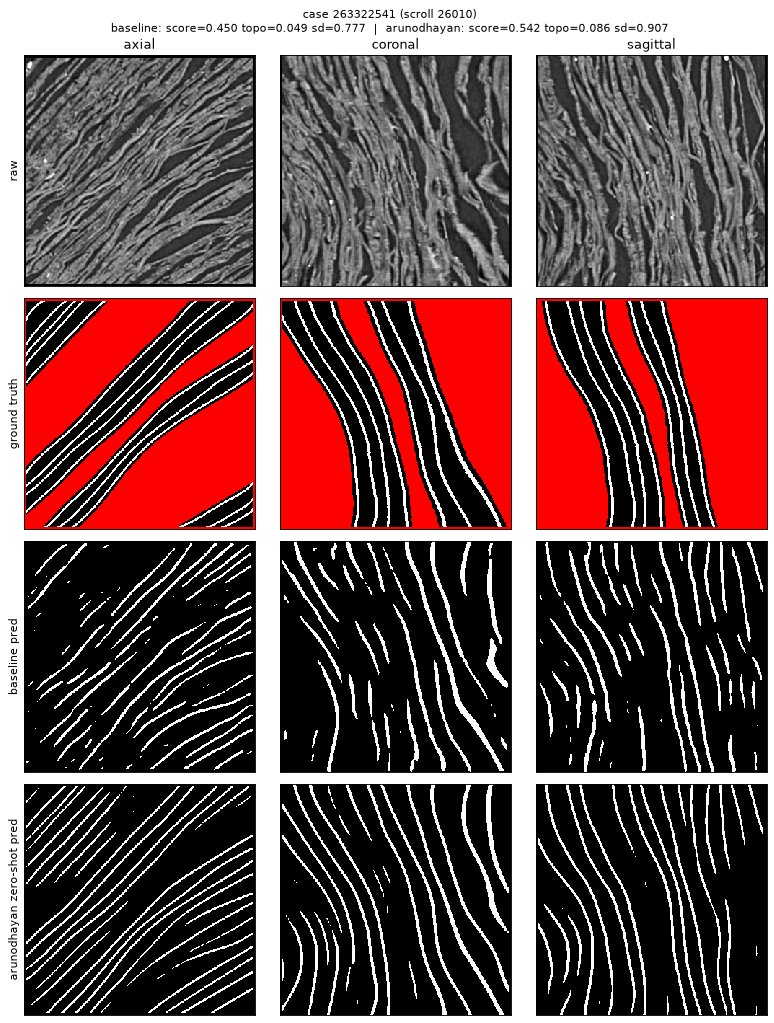

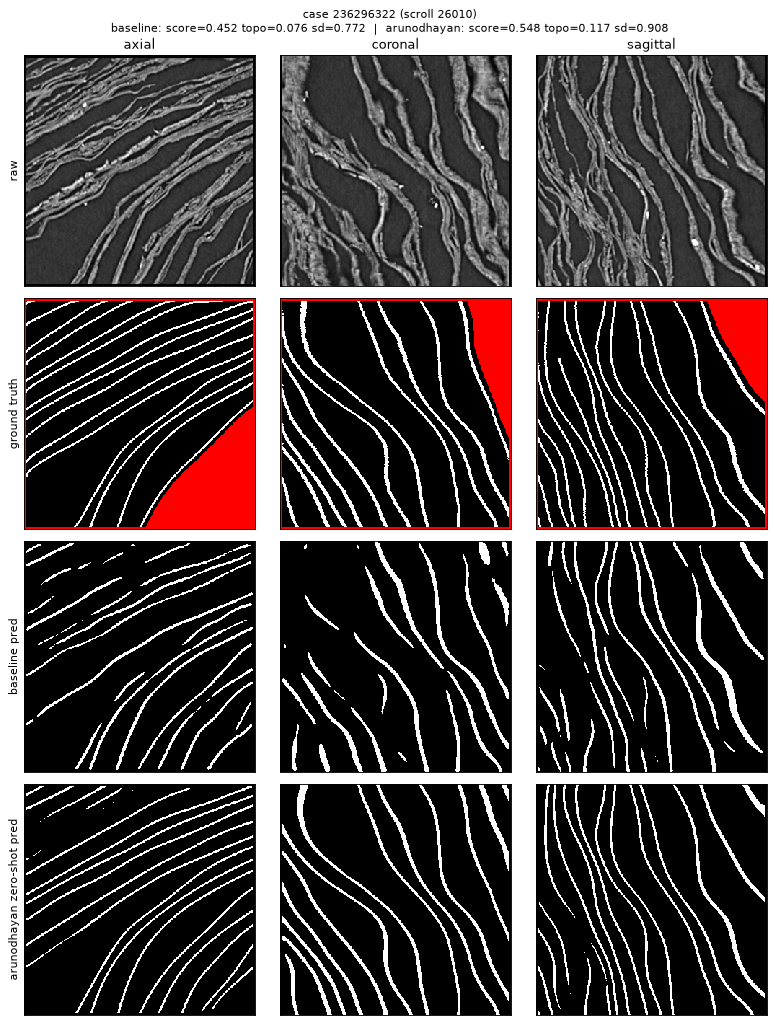

In [5]:
for case_id in overlap:
    plot_case(case_id)

## Single-case lookup

Change `case_id` below to inspect any specific case (e.g. one where the two models diverge
most, not just the shared-worst ones above).

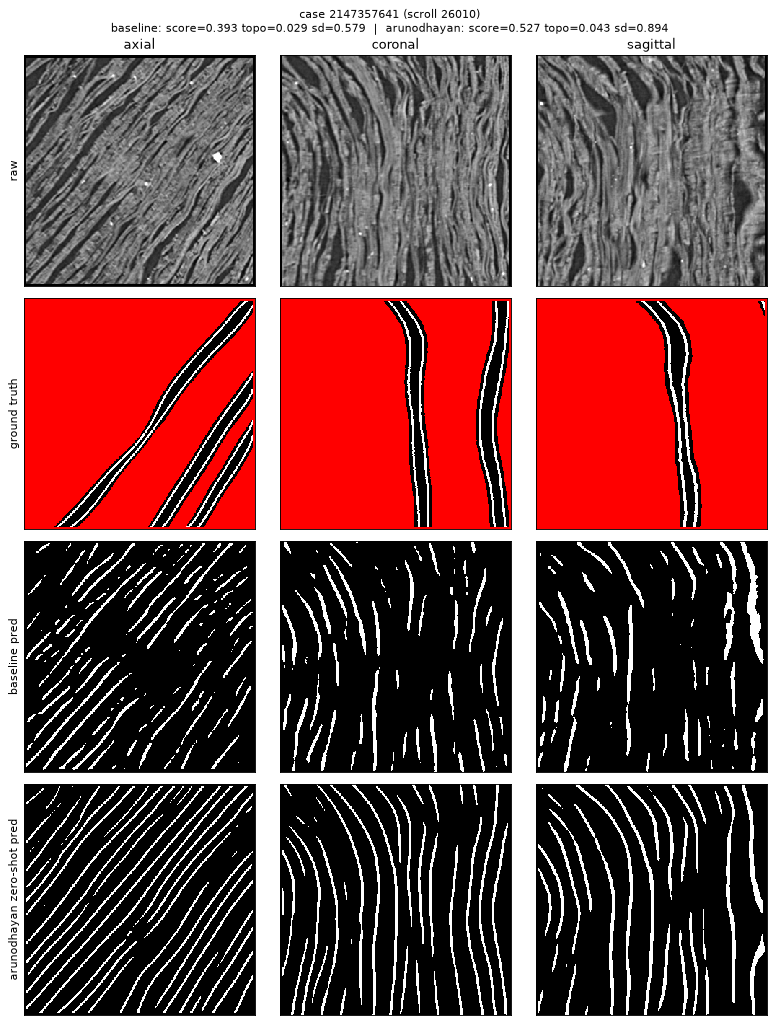

In [6]:
case_id = worst_baseline[0]
plot_case(case_id)